In [5]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv('/content/Diamonds Prices2022.csv')
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [7]:
df = df.drop(columns='Unnamed: 0')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [8]:
df.shape

(53943, 10)

In [9]:
df['x'].max()

10.74

In [10]:
df['x'].min()

0.0

## INSPECT ZERO COLUMNS OF X, Y, Z ##

In [11]:
df[df['x'] == 0]

,carat,cut,color,clarity,depth,table,price,x,y,z
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.0,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.0,0.00,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.0,0.00,0.0
24520,1.56,Ideal,G,VS2,62.2,54.0,12800,0.0,0.00,0.0
26243,1.20,Premium,D,VVS1,62.1,59.0,15686,0.0,0.00,0.0
27429,2.25,Premium,H,SI2,62.8,59.0,18034,0.0,0.00,0.0
49556,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.00,0.0
49557,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.00,0.0


In [12]:
df[df['y'] == 0]

,carat,cut,color,clarity,depth,table,price,x,y,z
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.0,0.0,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.0,0.0,0.0
24520,1.56,Ideal,G,VS2,62.2,54.0,12800,0.0,0.0,0.0
26243,1.20,Premium,D,VVS1,62.1,59.0,15686,0.0,0.0,0.0
27429,2.25,Premium,H,SI2,62.8,59.0,18034,0.0,0.0,0.0
49556,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.0,0.0
49557,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.0,0.0


In [13]:
df[df['z'] == 0]

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


In [14]:
# Step 1 — Flag zeros as NaN (they are missing, not zero)
df[['x', 'y', 'z']] = df[['x', 'y', 'z']].replace(0, np.nan)

print("Missing after replacement:")
print(df[['x', 'y', 'z']].isnull().sum())

Missing after replacement:
x     8
y     7
z    20
dtype: int64


In [15]:
# Step 2 — Check the scale of the problem
total = len(df)
bad = df[['x', 'y', 'z']].isnull().any(axis=1).sum()
print(f"{bad} rows affected ({bad/total*100:.2f}% of data)")

20 rows affected (0.04% of data)


In [16]:
# Step 3 — Impute using carat-grouped median (smarter than global median)
# Carat bins: diamonds of similar carat should have similar dimensions
df['carat_bin'] = pd.cut(df['carat'], bins=10)

for col in ['x', 'y', 'z']:
    df[col] = df.groupby('carat_bin')[col].transform(
        lambda g: g.fillna(g.median())
    )

# Fallback: if any NaN remains (edge bin with all zeros), use global median
for col in ['x', 'y', 'z']:
    df[col] = df[col].fillna(df[col].median())

df.drop(columns='carat_bin', inplace=True)

/tmp/ipykernel_6198/831673053.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby('carat_bin')[col].transform(


In [17]:
# Step 4 — Verify no zeros or NaNs remain
print(df[['x', 'y', 'z']].isnull().sum())
print((df[['x', 'y', 'z']] == 0).sum())  # should all be 0

x    0
y    0
z    0
dtype: int64
x    0
y    0
z    0
dtype: int64


In [18]:
# Step 5 — Optional: sanity check with a derived feature
# For a round brilliant diamond: volume ≈ x * y * z * 0.0061 ≈ carat
df['volume_check'] = df['x'] * df['y'] * df['z'] * 0.0061
df[['carat', 'volume_check']].corr()  # should be ~0.99

,carat,volume_check
carat,1.000000,0.978295
volume_check,0.978295,1.000000


# CHECK DUPLICATE ROWS

In [19]:
df.duplicated().sum()

np.int64(149)

In [20]:
df[df.duplicated()]

,carat,cut,color,clarity,depth,table,price,x,y,z,volume_check
1005,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66,0.770582
1006,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66,0.770582
1007,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66,0.770582
1008,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66,0.770582
2025,1.52,Good,E,I1,57.3,58.0,3105,7.53,7.42,4.28,1.458722
...,...,...,...,...,...,...,...,...,...,...,...
50079,0.51,Ideal,F,VVS2,61.2,56.0,2203,5.19,5.17,3.17,0.518856
52861,0.50,Fair,E,VS2,79.0,73.0,2579,5.21,5.18,4.09,0.673319
53940,0.71,Premium,E,SI1,60.5,55.0,2756,5.79,5.74,3.49,0.707531
53941,0.71,Premium,F,SI1,59.8,62.0,2756,5.74,5.73,3.43,0.688162


In [21]:
df = df.drop_duplicates()

In [22]:
# Check ALL remaining columns for nulls (no column names hardcoded)
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,volume_check
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,0.233032
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,0.210486
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,0.232269
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,0.285020
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,0.316695


In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df[df.duplicated()]

,carat,cut,color,clarity,depth,table,price,x,y,z,volume_check


In [27]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,volume_check
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,0.233032
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,0.210486
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,0.232269
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,0.285020
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,0.316695


In [28]:
df = df.rename(columns={'x': 'zirconia_length', 'y': 'zirconia_width', 'z': 'zirconia_height'})
display(df.head())

,carat,cut,color,clarity,depth,table,price,zirconia_length,zirconia_width,zirconia_height,volume_check
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,0.233032
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,0.210486
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,0.232269
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,0.285020
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,0.316695


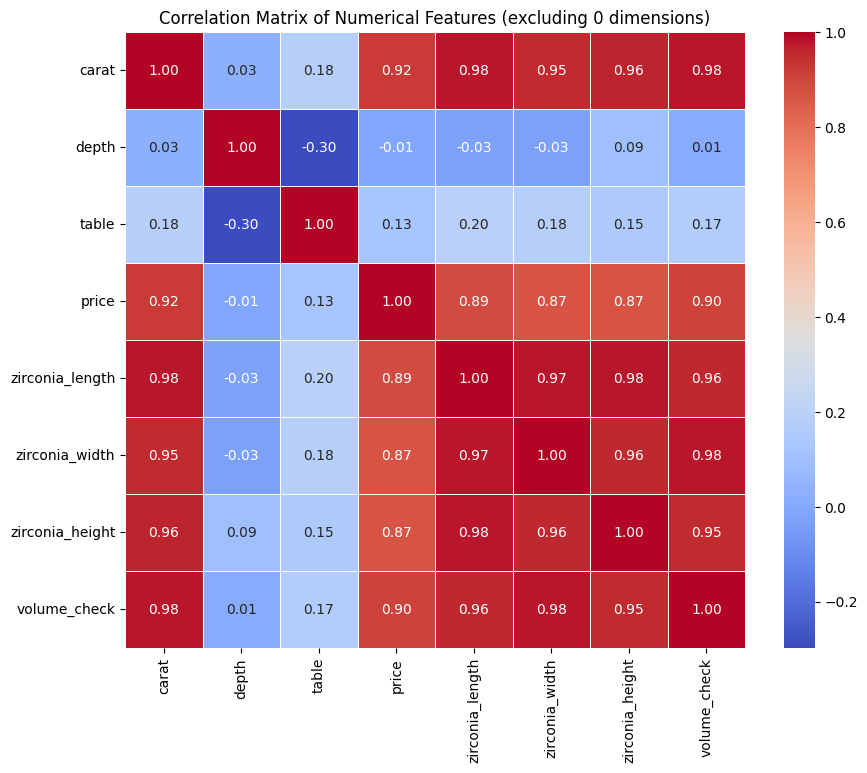

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features (excluding 0 dimensions)')
plt.show()

VOLUME_CHECK is a good predictor of price @90%...so it will be included in data for prediction:

volume = length × width × height

In [30]:
# Rename volume_check → volume (it's now a real feature, not a check)
df.rename(columns={'volume_check': 'volume'}, inplace=True)

# Verify
print(df.columns.tolist())
df[['zirconia_length', 'zirconia_width', 'zirconia_height', 'volume']].head()

['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'zirconia_length', 'zirconia_width', 'zirconia_height', 'volume']


,zirconia_length,zirconia_width,zirconia_height,volume
0,3.95,3.98,2.43,0.233032
1,3.89,3.84,2.31,0.210486
2,4.05,4.07,2.31,0.232269
3,4.20,4.23,2.63,0.285020
4,4.34,4.35,2.75,0.316695


# ENCODING

In [33]:
unique_cut = df['cut'].unique()
unique_color = df['color'].unique()
unique_clarit = df['clarity'].unique()

print("Unique values in 'cut':", unique_cut)
print("Unique values in 'color':", unique_color)
print("Unique values in 'clarity':", unique_clarit)

Unique values in 'cut': ['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
Unique values in 'color': ['E' 'I' 'J' 'H' 'F' 'G' 'D']
Unique values in 'clarity': ['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


In [34]:
# The correct quality orderings for diamonds
cut_order    = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order  = ['J', 'I', 'H', 'G', 'F', 'E', 'D']        # J=worst, D=best
clarity_order= ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

In [35]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

# Define encoder with explicit category order
encoder = OrdinalEncoder(
    categories=[cut_order, color_order, clarity_order],
    dtype=int                      # returns integers, not floats
)

# Fit and transform
df[['cut', 'color', 'clarity']] = encoder.fit_transform(
    df[['cut', 'color', 'clarity']]
)

df[['cut', 'color', 'clarity']].head(10)

,cut,color,clarity
0,4,5,1
1,3,5,2
2,1,5,4
3,3,1,3
4,1,0,1
5,2,0,5
6,2,1,6
7,2,2,2
8,0,5,3
9,2,2,4


CONFIRMING MAPPING IS CORRECT:

In [36]:
# Verify the mapping is correct
for col, order in zip(['cut', 'color', 'clarity'],
                      [cut_order, color_order, clarity_order]):
    print(f"\n{col} encoding:")
    for i, val in enumerate(order):
        print(f"  {val} → {i}")


cut encoding:
  Fair → 0
  Good → 1
  Very Good → 2
  Premium → 3
  Ideal → 4

color encoding:
  J → 0
  I → 1
  H → 2
  G → 3
  F → 4
  E → 5
  D → 6

clarity encoding:
  I1 → 0
  SI2 → 1
  SI1 → 2
  VS2 → 3
  VS1 → 4
  VVS2 → 5
  VVS1 → 6
  IF → 7


In [37]:
# Sanity check — value ranges should match category counts
print("\nValue ranges after encoding:")
for col in ['cut', 'color', 'clarity']:
    print(f"  {col}: min={df[col].min()}, max={df[col].max()}")

# Expected:
# cut     → 0 to 4   (5 categories)
# color   → 0 to 6   (7 categories)
# clarity → 0 to 7   (8 categories)


Value ranges after encoding:
  cut: min=0, max=4
  color: min=0, max=6
  clarity: min=0, max=7


In [38]:
# Final check — full df overview after encoding
print("Shape:", df.shape)
print("dtypes:\n", df.dtypes)
df.describe()

Shape: (53794, 11)
dtypes:
 carat              float64
cut                  int64
color                int64
clarity              int64
depth              float64
table              float64
price                int64
zirconia_length    float64
zirconia_width     float64
zirconia_height    float64
volume             float64
dtype: object


,carat,cut,color,clarity,depth,table,price,zirconia_length,zirconia_width,zirconia_height,volume
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,2.904134,3.406086,3.051920,61.748080,57.458109,3933.065082,5.732101,5.735422,3.540259,0.792458
std,0.47339,1.116098,1.701117,1.646857,1.429909,2.233679,3988.114460,1.118887,1.139696,0.702160,0.476836
min,0.20000,0.000000,0.000000,0.000000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000,0.193419
25%,0.40000,2.000000,2.000000,2.000000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000,0.397842
50%,0.70000,3.000000,3.000000,3.000000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000,0.700630
75%,1.04000,4.000000,5.000000,4.000000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.040000,1.042160
max,5.01000,4.000000,6.000000,7.000000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000,23.427648


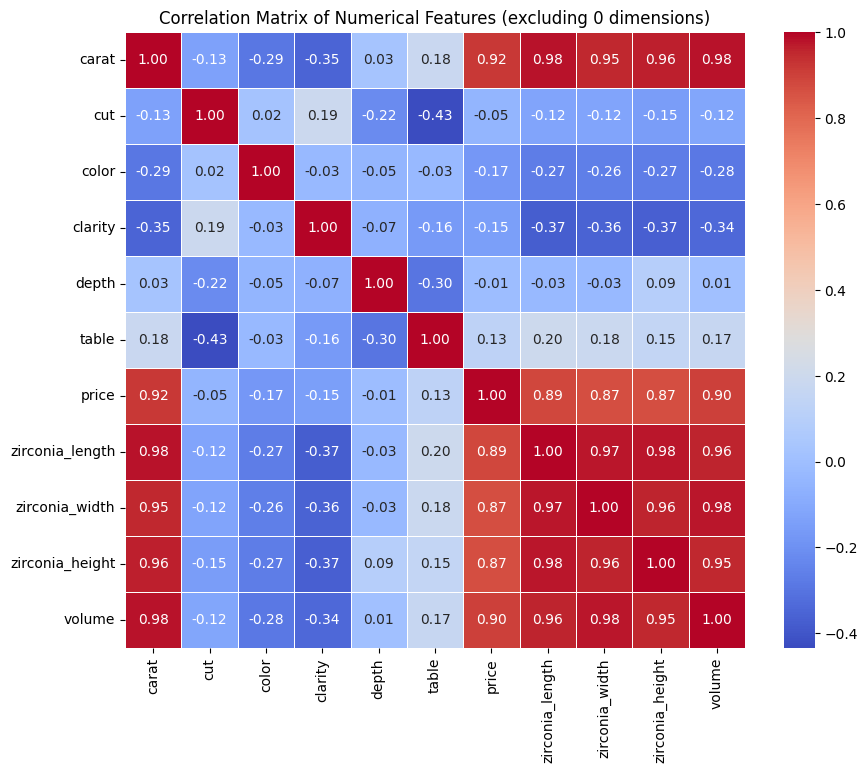

In [39]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features (excluding 0 dimensions)')
plt.show()

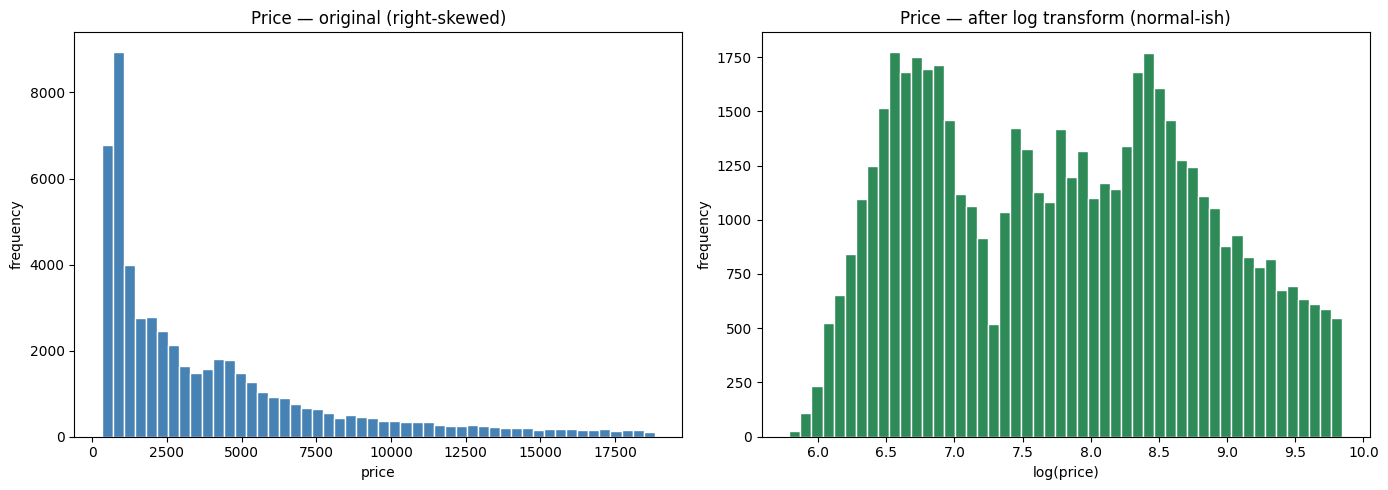

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize before transformation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price — original (right-skewed)')
axes[0].set_xlabel('price')
axes[0].set_ylabel('frequency')

axes[1].hist(np.log1p(df['price']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Price — after log transform (normal-ish)')
axes[1].set_xlabel('log(price)')
axes[1].set_ylabel('frequency')

plt.tight_layout()
plt.show()

In [41]:
# Apply log1p transformation
# log1p = log(1 + price) — safer than log() because it handles 0 values gracefully
df['price'] = np.log1p(df['price'])

print("Price stats after log transform:")
print(df['price'].describe().round(4))

Price stats after log transform:
count    53794.0000
mean         7.7878
std          1.0139
min          5.7900
25%          6.8586
50%          7.7841
75%          8.5807
max          9.8429
Name: price, dtype: float64


In [42]:
# Verify skewness improved
from scipy import stats

skew = stats.skew(df['price'])
print(f"\nSkewness after log transform: {skew:.4f}")


Skewness after log transform: 0.1149


### Good result: between -0.5 and +0.5 is considered near-normal

we have 0.1149

# TRAIN TEST SPLIT

In [43]:
from sklearn.model_selection import train_test_split
import os

# Train/test split — 80/20 is standard for this dataset size
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42     # always set this — ensures reproducibility
)

print("Split summary:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test:  {y_test.shape}")

Split summary:
  X_train: (43035, 10)
  X_test:  (10759, 10)
  y_train: (43035,)
  y_test:  (10759,)


In [44]:
# Recombine X and y for saving (easier to work with in modeling notebook)
train_df = pd.concat([X_train, y_train], axis=1)
test_df  = pd.concat([X_test,  y_test],  axis=1)

print("Train set:", train_df.shape)
print("Test set: ", test_df.shape)

Train set: (43035, 11)
Test set:  (10759, 11)


In [45]:
# Create artifacts/ folder and save
os.makedirs('artifacts', exist_ok=True)

train_df.to_csv('artifacts/train.csv', index=False)
test_df.to_csv('artifacts/test.csv',   index=False)

# Save the full cleaned df too — useful reference
df.to_csv('artifacts/cleaned_data.csv', index=False)

print("✅ Saved to artifacts/:")
print("   - train.csv")
print("   - test.csv")
print("   - cleaned_data.csv")

✅ Saved to artifacts/:
   - train.csv
   - test.csv
   - cleaned_data.csv
